In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")
import SSMCMain.ModifiedMiCRM.MinimalModelV2, SSMCMain.ModifiedMiCRM.MinimalModelV3

In [106]:
includet("../../../scripts/figures_util.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Looking at the beta dists

In [8]:
fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1]; xlabel="x", ylabel="pdf")
xlims!(ax, 0, 1)

sg = SliderGrid(fig[2, 1],
    (label="alpha", range=0.05:0.05:10.0, startvalue=2.0, format="{:.2f}"),
    (label="beta", range=0.05:0.05:10.0, startvalue=5.0, format="{:.2f}"),
)
alpha = sg.sliders[1].value
beta_ = sg.sliders[2].value

tg = GridLayout(fig[3, 1]; tellwidth=false)
logy = Toggle(tg[1, 1]; active=false)
Label(tg[1, 2], "log10 y-axis")

xs = range(0, 1; length=1001)
ys = lift((a, b) -> clamp.(pdf.(Beta(a, b), xs), eps(), Inf), alpha, beta_)

lines!(ax, xs, ys; linewidth=2)
on(logy.active) do uselog
    if uselog
        # autolimits on a log axis would span the whole tail
        ymax = maximum(filter(isfinite, ys[]); init=1.0)
        ylims!(ax, ymax / 1e10, 2 * ymax)
        ax.yscale = log10
    else
        ax.yscale = identity
        ylims!(ax, nothing, nothing)
    end
end

Label(fig[0, 1], lift((a, b) -> "Beta(alpha=$(round(a, digits=2)), beta=$(round(b, digits=2)))", alpha, beta_),
    tellwidth=false)

display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

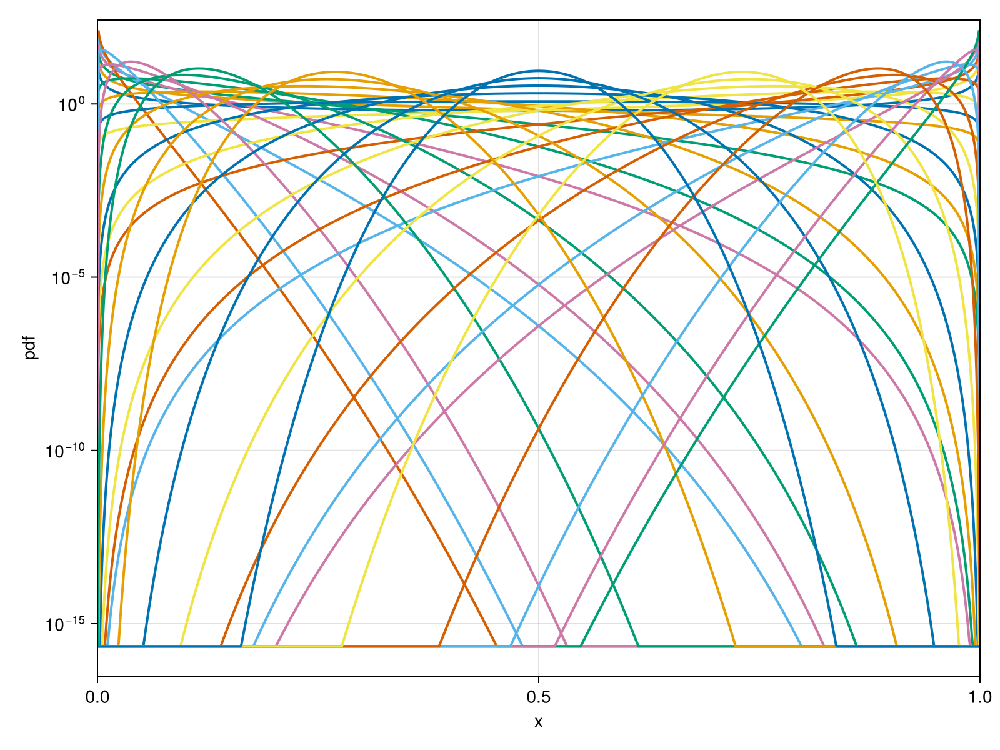

In [76]:
alphabeta_pairs = [
    (2.0, 5.0),
    (0.5, 0.5),
    (5.0, 1.0),
    (1.0, 1.0),
]
xx = 2 .^ range(-1, 6, 6)
alphabeta_pairs = [(a, b) for a in xx for b in xx]
uselog = true  # switch between log10 and linear y scale

fig = Figure(size=(800, 600))
ax = Axis(fig[1, 1]; xlabel="x", ylabel="pdf", yscale=uselog ? log10 : identity)
xlims!(ax, 0, 1)

xs = range(0, 1; length=1001)
for (a, b) in alphabeta_pairs
    ys = clamp.(pdf.(Beta(a, b), xs), eps(), Inf)
    lines!(ax, xs, ys; label="Beta($a, $b)", linewidth=2)
end
# axislegend(ax)

fig

In [77]:
extrema(map(alphabeta_pairs) do xx
    b = Beta(xx...)
    mean(b)
end)

(0.007751937984496124, 0.9922480620155039)

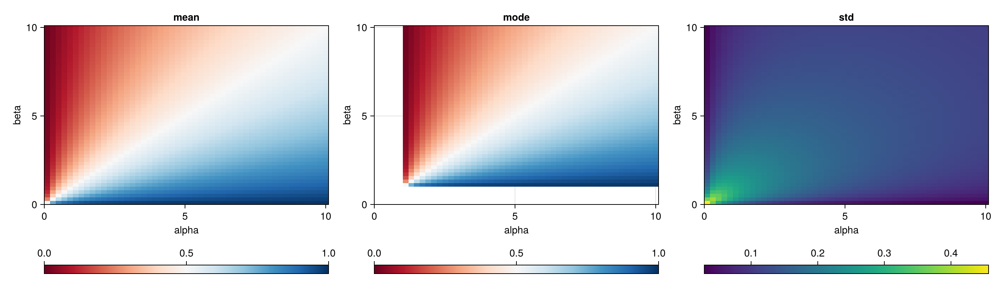

In [24]:
arange = range(0.1, 10; length=50)
brange = range(0.1, 10; length=50)

betamean(a, b) = a / (a + b)
betastd(a, b) = sqrt(a * b / ((a + b)^2 * (a + b + 1)))
betamode(a, b) = (a > 1 && b > 1) ? (a - 1) / (a + b - 2) : NaN

meangrid = [betamean(a, b) for a in arange, b in brange]
modegrid = [betamode(a, b) for a in arange, b in brange]
stdgrid = [betastd(a, b) for a in arange, b in brange]

fig = Figure(size=(1400, 400))
panels = [
    ("mean", meangrid, :RdBu, (0, 1)),
    ("mode", modegrid, :RdBu, (0, 1)),
    ("std", stdgrid, :viridis, nothing),
]
for (i, (title, grid, cmap, crange)) in enumerate(panels)
    ax = Axis(fig[1, i]; xlabel="alpha", ylabel="beta", title=title)
    kwargs = crange === nothing ? (; colormap=cmap) : (; colormap=cmap, colorrange=crange)
    hm = heatmap!(ax, arange, brange, grid; kwargs...)
    Colorbar(fig[2, i], hm; vertical=false)
end

fig

# Making and saving plots

## Outcome proportions vs K

In [94]:
function plot_outcome_proportions!(figpos, lalphai, lbetai; arrs=arrs, fmd=fmd, legend=true, show_bad=true)
    numKs, numlalphas, numlbetas = length(fmd.Ks), length(fmd.lalphas), length(fmd.lbetas)
    zeromat() = zeros(Int, numKs, numlalphas, numlbetas)

    good_codes = [1, 2, 3]
    good_labels = ["Extinct", "Stable", "Unstable"]
    good_colors = [PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable()]

    counts = [get(arrs, code, zeromat())[:, lalphai, lbetai] for code in good_codes]
    totals = sum(get(arrs, code, zeromat())[:, lalphai, lbetai] for code in keys(arrs))
    bad_counts = totals .- sum(counts)

    alpha, beta_ = fmd.lalphas[lalphai], fmd.lbetas[lbetai]
    d = Beta(alpha, beta_)
    ax = Axis(figpos;
        xscale=log10,
        xlabel="K",
        ylabel="Proportion",
        title=(@sprintf "alpha=%.4g, beta=%.4g\nmean=%.3g, std=%.3g" alpha beta_ mean(d) std(d)),
    )

    for (c, label, color) in zip(counts, good_labels, good_colors)
        plot_binom_sample!(ax, fmd.Ks, c, totals;
            proportions=true,
            color,
            sl_kwargs=(; label),
        )
    end
    if show_bad
        plot_binom_sample!(ax, fmd.Ks, bad_counts, totals;
            proportions=true,
            color=PaperColors.other(),
            sl_kwargs=(; label="Bad"),
        )
    end

    legend && axislegend(ax; position=:rt)
    ax
end
function plot_outcome_proportions_grid(fname; figure=(;), kwargs...)
    f = jldopen(fname)
    fmd = f["metadata"]
    df = f["df"]
    close(f)

    arrs = make_count_arrays(df)
    numlalphas, numlbetas = length(fmd.lalphas), length(fmd.lbetas)

    default_fig_kwargs = (; size=(350 * numlbetas + 80, 200 * numlalphas + 130))
    fig = Figure(; merge(default_fig_kwargs, figure)...)
    for lalphai in 1:numlalphas, lbetai in 1:numlbetas
        plot_outcome_proportions!(fig[lalphai, lbetai], lalphai, lbetai; arrs, fmd, legend=false, kwargs...)
    end

    for lbetai in 1:numlbetas
        Label(fig[0, lbetai], (@sprintf "beta=%.4g" fmd.lbetas[lbetai]); tellwidth=false, fontsize=16, font=:bold)
    end
    for lalphai in 1:numlalphas
        Label(fig[lalphai, 0], (@sprintf "alpha=%.4g" fmd.lalphas[lalphai]); rotation=pi/2, tellheight=false, fontsize=16, font=:bold)
    end

    Legend(fig[numlalphas + 1, 1:numlbetas],
        [LineElement(; color) for color in (PaperColors.extinct(), PaperColors.stable(), PaperColors.unstable(), PaperColors.other())],
        ["Extinct", "Stable", "Unstable", "Bad"];
        orientation=:horizontal,
    )

    fig
end

plot_outcome_proportions_grid (generic function with 1 method)

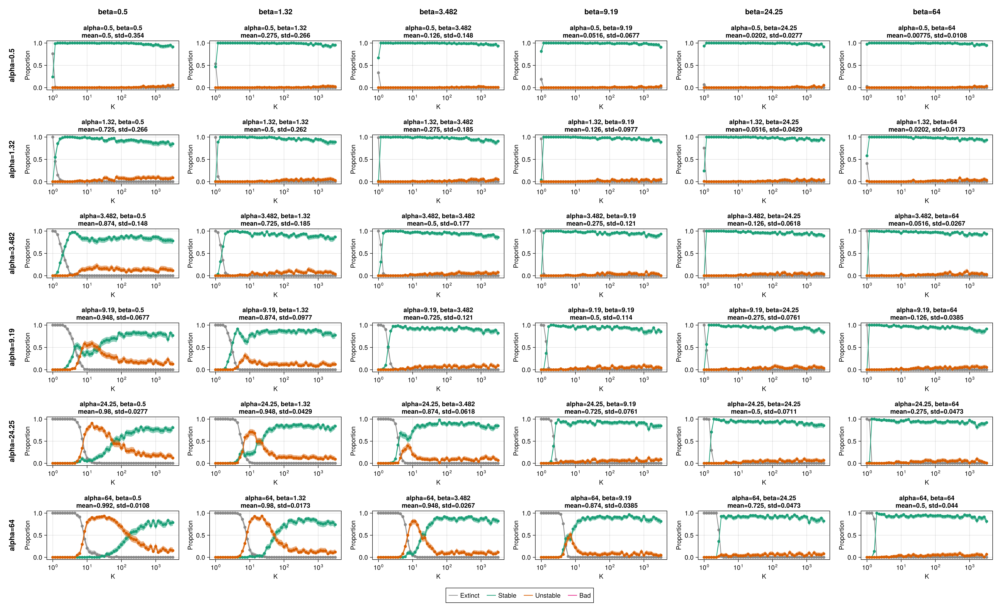

In [101]:
mkpath("./main1_plots")

fig = plot_outcome_proportions_grid("./main1.jld2";
    show_bad=false,
)
Makie.save("./main1_plots/proportions.pdf", fig)
fig

## Showing the distributions from the run

In [103]:
function plot_beta_dist!(figpos, lalphai, lbetai; fmd=fmd)
    alpha, beta_ = fmd.lalphas[lalphai], fmd.lbetas[lbetai]
    d = Beta(alpha, beta_)

    ax = Axis(figpos;
        xlabel="x",
        ylabel="pdf",
        title=(@sprintf "alpha=%.4g, beta=%.4g\nmean=%.3g, std=%.3g" alpha beta_ mean(d) std(d)),
    )
    xlims!(ax, 0, 1)

    xs = range(0, 1; length=1001)
    ys = clamp.(pdf.(d, xs), eps(), Inf)
    lines!(ax, xs, ys; linewidth=2)

    ax
end
function plot_beta_dist_grid(fname; figure=(;))
    f = jldopen(fname)
    fmd = f["metadata"]
    close(f)

    numlalphas, numlbetas = length(fmd.lalphas), length(fmd.lbetas)

    default_fig_kwargs = (; size=(350 * numlbetas + 80, 150 * numlalphas + 130))
    fig = Figure(; merge(default_fig_kwargs, figure)...)
    for lalphai in 1:numlalphas, lbetai in 1:numlbetas
        plot_beta_dist!(fig[lalphai, lbetai], lalphai, lbetai; fmd)
    end

    for lbetai in 1:numlbetas
        Label(fig[0, lbetai], (@sprintf "beta=%.4g" fmd.lbetas[lbetai]); tellwidth=false, fontsize=16, font=:bold)
    end
    for lalphai in 1:numlalphas
        Label(fig[lalphai, 0], (@sprintf "alpha=%.4g" fmd.lalphas[lalphai]); rotation=pi/2, tellheight=false, fontsize=16, font=:bold)
    end

    fig
end

plot_beta_dist_grid (generic function with 1 method)

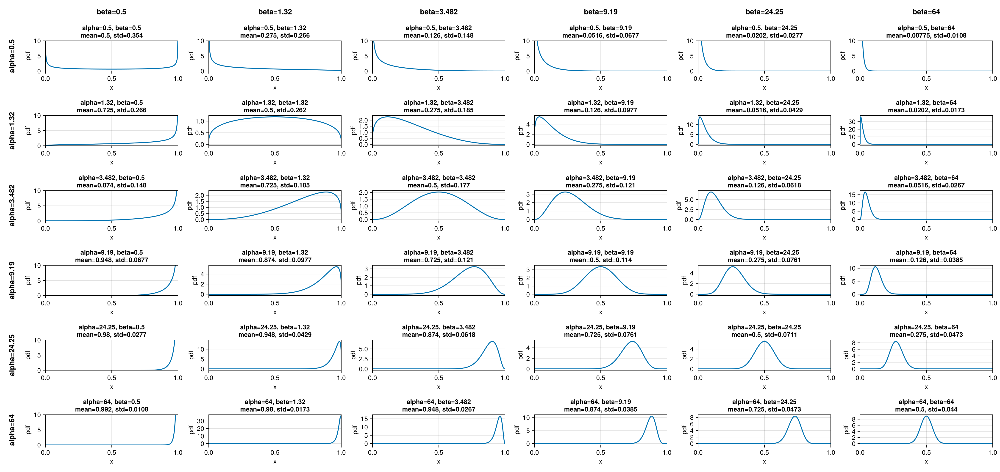

In [105]:
mkpath("./main1_plots")

fig = plot_beta_dist_grid("./main1.jld2")
Makie.save("./main1_plots/distributions.pdf", fig)
fig

# Playing around

In [104]:
f = jldopen("./main1.jld2")
fmd = f["metadata"]
df = f["df"]
close(f)

arrs = make_count_arrays(df)
instab_counts = dropdims(sum(arrs[3]; dims=1); dims=1)  # alpha (rows) x beta (cols), summed over K and repeats

xx = length(fmd.Ks) * fmd.num_repeats
instab_props = instab_counts ./ xx

6×6 Matrix{Float64}:
 0.00826667  0.0064     0.0044     0.00546667  0.0056     0.00426667
 0.0453333   0.0210667  0.0158667  0.0169333   0.0146667  0.0156
 0.107733    0.0489333  0.0314667  0.0238667   0.0249333  0.0233333
 0.214667    0.107333   0.0496     0.0350667   0.0306667  0.0296
 0.309733    0.1896     0.0964     0.0457333   0.038      0.0317333
 0.3932      0.279067   0.173333   0.088       0.0474667  0.0342667